In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you have a CSV file, load it like this:
# df = pd.read_csv('cgpa_data.csv')
# X = df['CGPA'].values
# y = df['Package'].values

# For demonstration/testing, let's generate a synthetic CGPA dataset:
np.random.seed(42)
X = np.linspace(6.0, 10.0, 100)  # CGPA values
y = 3.5 * X - 10 + np.random.normal(0, 0.5, 100) # Target package/score

print(f"Data shape - X: {X.shape}, y: {y.shape}")

Data shape - X: (100,), y: (100,)


In [2]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    w = 0.0
    b = 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        # 1. Predict
        y_pred = w * X + b

        # 2. Calculate Mean Squared Error (MSE) loss
        loss = (1 / n) * np.sum((y_pred - y) ** 2)
        loss_history.append(loss)

        # 3. Compute gradients
        dw = (2 / n) * np.sum((y_pred - y) * X)
        db = (2 / n) * np.sum(y_pred - y)

        # 4. Update parameters using learning rate
        w -= learning_rate * dw
        b -= learning_rate * db

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f} | w: {w:.4f}, b: {b:.4f}")

    return w, b, loss_history

# Run gradient descent
w_opt, b_opt, losses = gradient_descent(X, y, learning_rate=0.01, epochs=1000)
print(f"\nFinal Optimized Parameters -> w: {w_opt:.4f}, b: {b_opt:.4f}")

Epoch 0 | Loss: 339.1651 | w: 2.9674, b: 0.3590
Epoch 100 | Loss: 2.3029 | w: 2.2881, b: -0.1508
Epoch 200 | Loss: 2.1376 | w: 2.3375, b: -0.5543
Epoch 300 | Loss: 1.9853 | w: 2.3849, b: -0.9415
Epoch 400 | Loss: 1.8450 | w: 2.4304, b: -1.3132
Epoch 500 | Loss: 1.7157 | w: 2.4741, b: -1.6699
Epoch 600 | Loss: 1.5966 | w: 2.5160, b: -2.0123
Epoch 700 | Loss: 1.4869 | w: 2.5562, b: -2.3410
Epoch 800 | Loss: 1.3858 | w: 2.5949, b: -2.6564
Epoch 900 | Loss: 1.2927 | w: 2.6319, b: -2.9591

Final Optimized Parameters -> w: 2.6672, b: -3.2469


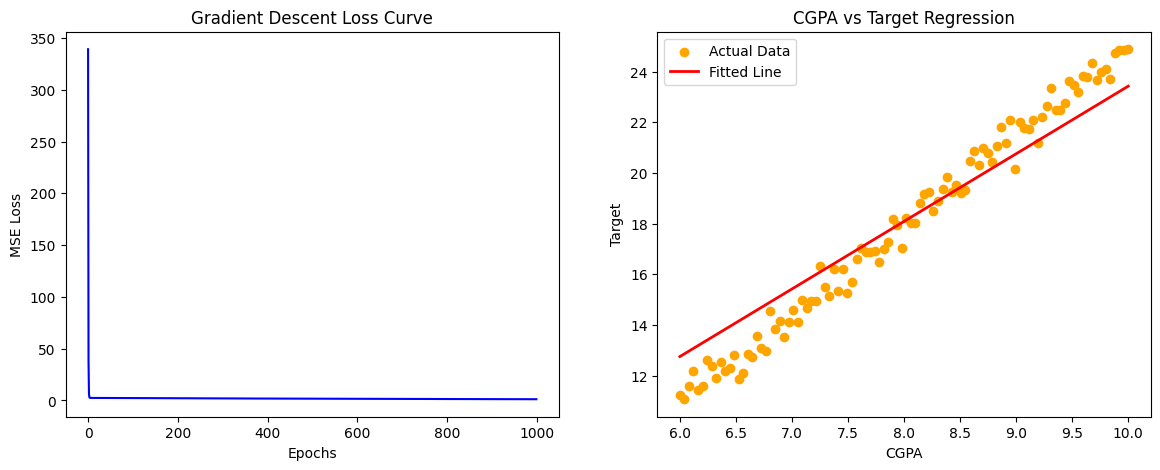

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Reduction over Epochs
axes[0].plot(losses, color='blue')
axes[0].set_title('Gradient Descent Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')

# Plot 2: Fitted Line vs Data Points
axes[1].scatter(X, y, color='orange', label='Actual Data')
axes[1].plot(X, w_opt * X + b_opt, color='red', linewidth=2, label='Fitted Line')
axes[1].set_title('CGPA vs Target Regression')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Target')
axes[1].legend()

plt.show()